In [2]:
import numpy as np
import matplotlib.pyplot as plt

from setup3D import StartUp3D
from Maxwell3D import Maxwell3D
from mesh_reader3D import MeshReader3D

N = np.array([1,2,3,4,5])

erros = []
for n in range(len(N)):

    VX, VY, VZ, EToV = MeshReader3D('malhas3D/cavidade3D_grossa.msh')

    malha = StartUp3D(N[n],EToV,VX,VY,VZ)

    Ez = np.sin(np.pi*malha.x)*np.sin(np.pi*malha.y)
    Hx = np.zeros((malha.Np,malha.K))
    Hy = np.zeros((malha.Np,malha.K))
    Hz = np.zeros((malha.Np,malha.K))
    Ex = np.zeros((malha.Np,malha.K))
    Ey = np.zeros((malha.Np,malha.K))

    FinalTime = 5
    Hx, Hy, Hz, Ex, Ey, Ez, t_final = Maxwell3D(Hx,Hy,Hz,Ex,Ey,Ez,FinalTime,malha,CFL=0.4,pml=False)

    Ez_analitico = np.sin(np.pi*malha.x)*np.sin(np.pi*malha.y)*np.cos(np.pi*np.sqrt(2)*t_final)

    M = np.linalg.inv(malha.V @ malha.V.T) 

    erro_nodal = Ez - Ez_analitico

    integral_erro_sq = np.sum(malha.J * (erro_nodal * (M @ erro_nodal)))
    En = np.sqrt(integral_erro_sq)

    integral_analitico_sq = np.sum(malha.J * (Ez_analitico * (M @ Ez_analitico)))
    wt = np.sqrt(integral_analitico_sq)

    erro_L2_real = En / wt

    erros.append(erro_L2_real)


Número de vértices (VX): 228
Número de tetraedros (EToV): 668
Número de faces de contorno: 396
Tempo atual: 2.4083e-02 / 5.00e+00
Tempo atual: 4.8166e-02 / 5.00e+00
Tempo atual: 7.2249e-02 / 5.00e+00
Tempo atual: 9.6332e-02 / 5.00e+00
Tempo atual: 1.2041e-01 / 5.00e+00
Tempo atual: 1.4450e-01 / 5.00e+00
Tempo atual: 1.6858e-01 / 5.00e+00
Tempo atual: 1.9266e-01 / 5.00e+00
Tempo atual: 2.1675e-01 / 5.00e+00
Tempo atual: 2.4083e-01 / 5.00e+00
Tempo atual: 2.6491e-01 / 5.00e+00
Tempo atual: 2.8899e-01 / 5.00e+00
Tempo atual: 3.1308e-01 / 5.00e+00
Tempo atual: 3.3716e-01 / 5.00e+00
Tempo atual: 3.6124e-01 / 5.00e+00
Tempo atual: 3.8533e-01 / 5.00e+00
Tempo atual: 4.0941e-01 / 5.00e+00
Tempo atual: 4.3349e-01 / 5.00e+00
Tempo atual: 4.5757e-01 / 5.00e+00
Tempo atual: 4.8166e-01 / 5.00e+00
Tempo atual: 5.0574e-01 / 5.00e+00
Tempo atual: 5.2982e-01 / 5.00e+00
Tempo atual: 5.5391e-01 / 5.00e+00
Tempo atual: 5.7799e-01 / 5.00e+00
Tempo atual: 6.0207e-01 / 5.00e+00
Tempo atual: 6.2616e-01 / 5.0

Taxa de Convergência Espectral 3D (Sigma):
De N=1 para N=2 -> taxa sigma = 2.43
De N=2 para N=3 -> taxa sigma = 1.90
De N=3 para N=4 -> taxa sigma = 2.09
De N=4 para N=5 -> taxa sigma = 2.00


Para N = 1 -> erro = 5.08e-01
Para N = 2 -> erro = 4.48e-02
Para N = 3 -> erro = 6.72e-03
Para N = 4 -> erro = 8.29e-04
Para N = 5 -> erro = 1.13e-04


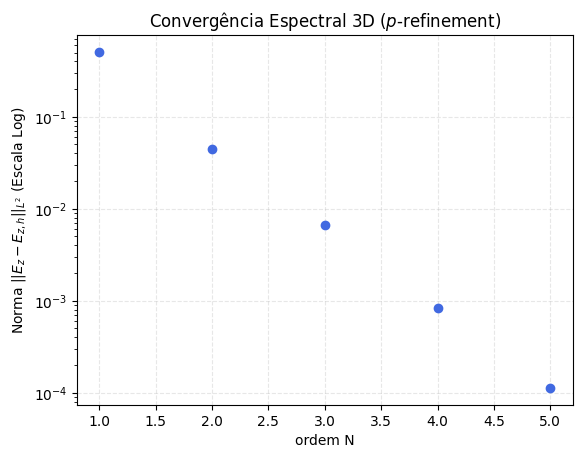

In [5]:
ordens_N = N
erros = np.array(erros)

print("Taxa de Convergência Espectral 3D (Sigma):")
for i in range(len(ordens_N)-1):
    N_antigo = ordens_N[i]
    N_novo = ordens_N[i+1]
    
    E_antigo = erros[i]
    E_novo = erros[i+1]
    
    sigma = - (np.log(E_novo) - np.log(E_antigo)) / (N_novo - N_antigo)
    
    print(f"De N={N_antigo} para N={N_novo} -> taxa sigma = {sigma:.2f}")

print('\n')
for j in range(len(N)):
    print(f'Para N = {N[j]} -> erro = {erros[j]:.2e}')

plt.figure()
plt.grid(alpha=0.3,ls='--')
plt.title(r'Convergência Espectral 3D ($p$-refinement)')
plt.semilogy(N,erros,'o',color='royalblue')
plt.ylabel(r'Norma $||E_z-E_{z,h}||_{L^2}$ (Escala Log)')
plt.xlabel('ordem N')
plt.show()